Dataset loaded successfully.
Dataset shape: (7043, 21)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Columns remaining after removing unnecessary columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']

Features shape: (7043, 18)
Target shape: (7043,)

Shape after encoding categorical variables:
(7043, 29)

Training data shape: (5634, 29)
Testing data shape: (7043, 29)

Logistic Regression model trained successfully.

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]

Accuracy: 0.7977288857345636
Accuracy (%): 79.77288857345636

Precision: 0.6394984326018809
Precision (%): 63.94984326018809

Recall: 0.5454545454545454
Recall (%): 54.54545454545454

F1-Score: 0.5887445887445888
F1-Score (%): 58.87445887

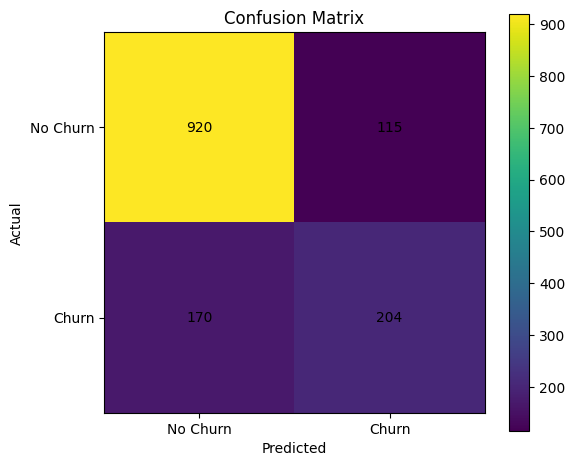


================ MODEL PERFORMANCE ================

   Metric    Score  Percentage
 Accuracy 0.797729   79.772889
Precision 0.639498   63.949843
   Recall 0.545455   54.545455
 F1-Score 0.588745   58.874459

              PART 4 COMPLETED

Accuracy :  79.77%
Precision:  63.95%
Recall   :  54.55%
F1-Score :  58.87%

The Logistic Regression model has been trained
and evaluated successfully.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nChurn distribution:")
print(df["Churn"].value_counts())

columns_to_drop = [
    "customerID",
    "TotalCharges"
]

df = df.drop(columns=columns_to_drop)

print("\nColumns remaining after removing unnecessary columns:")
print(df.columns.tolist())

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

X = pd.get_dummies(
    X,
    drop_first=True
)

print("\nShape after encoding categorical variables:")
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X.shape)

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

y_pred = model.predict(X_test)

print("\nFirst 20 predictions:")
print(y_pred[:20])

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\nPrecision:", precision)
print("Precision (%):", precision * 100)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\nRecall:", recall)
print("Recall (%):", recall * 100)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\nF1-Score:", f1)
print("F1-Score (%):", f1 * 100)

print("\n================ CLASSIFICATION REPORT ================\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n================ CONFUSION MATRIX ================\n")

print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Percentage"] = results["Score"] * 100

print("\n================ MODEL PERFORMANCE ================\n")

print(results.to_string(index=False))

print("\n====================================================")
print("              PART 4 COMPLETED")
print("====================================================")

print(f"\nAccuracy :  {accuracy * 100:.2f}%")
print(f"Precision:  {precision * 100:.2f}%")
print(f"Recall   :  {recall * 100:.2f}%")
print(f"F1-Score :  {f1 * 100:.2f}%")

print("\nThe Logistic Regression model has been trained")
print("and evaluated successfully.")